<a href="https://colab.research.google.com/github/ZukhrufianAbdullah/PCVK_Ganjil_2026/blob/main/Week-05/Week5_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

E-1 PERCOBAAN HISTOGRAM

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Library
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

Mounted at /content/drive


<BarContainer object of 256 artists>

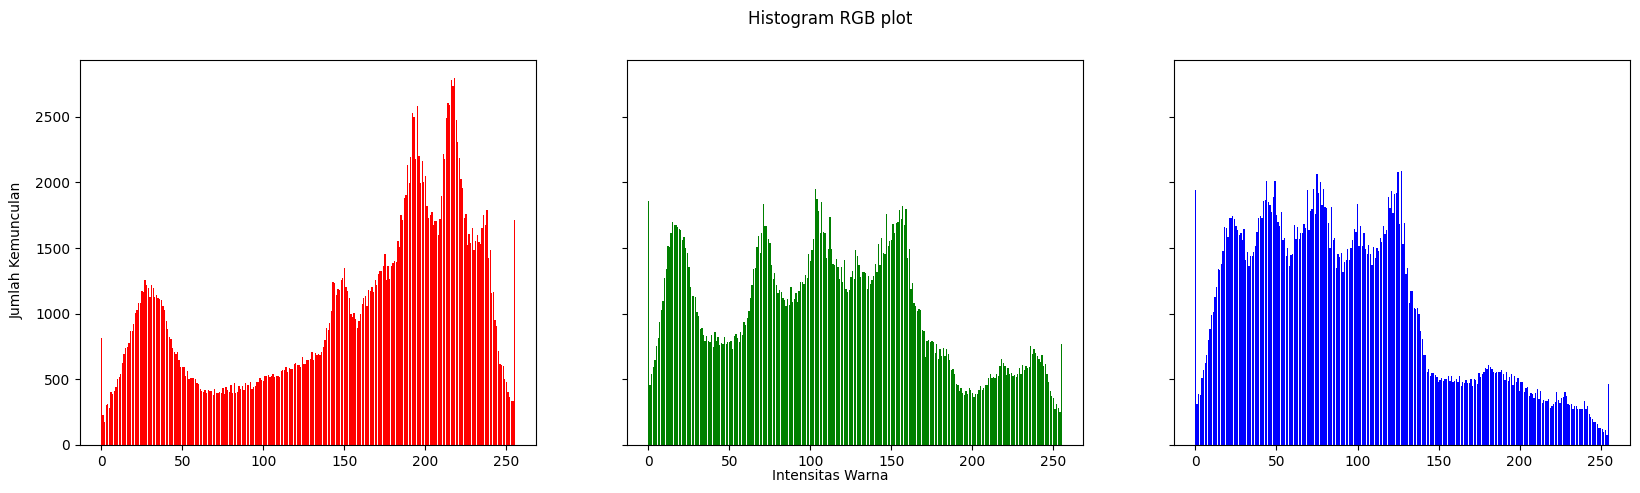

In [5]:
# Membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Gambar/Lenna.jpeg') #Lenna
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

<BarContainer object of 256 artists>

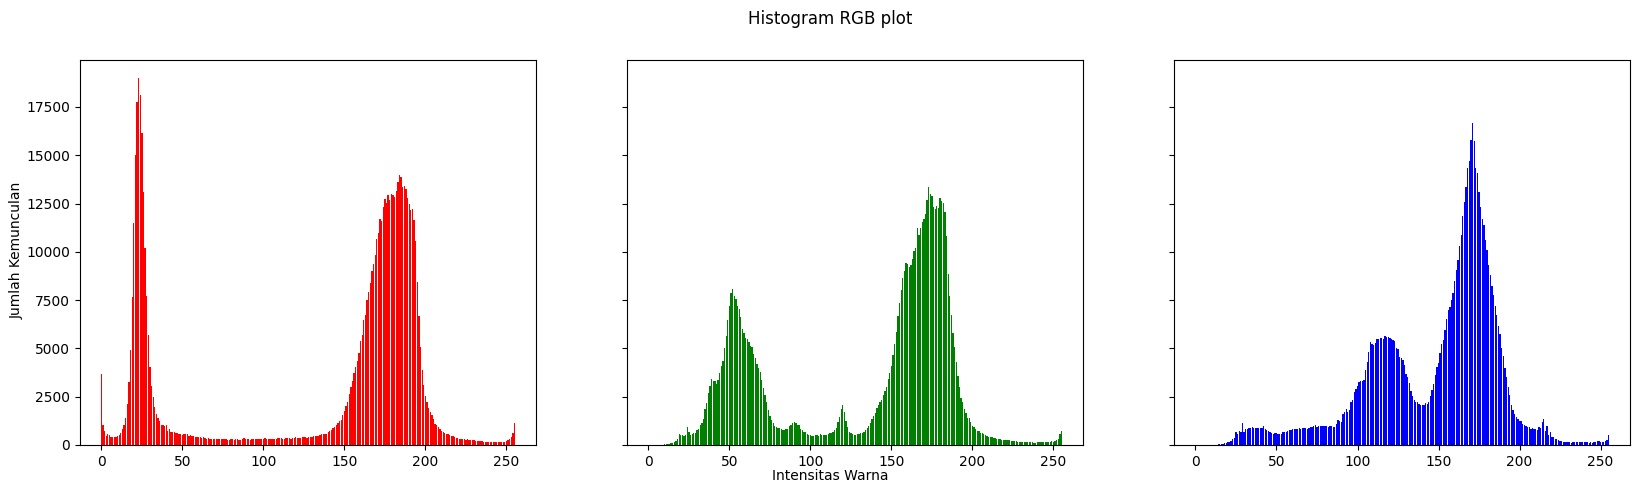

In [4]:
# Membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Gambar/ktm_baru.jpeg') #KTM
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

# PERTANYAAN PRAKTIKUM E1
1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [6]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Load image Lenna
img_lenna = cv.imread('/content/drive/MyDrive/PCVK/Gambar/Lenna.jpeg')
img_lenna_rgb = cv.cvtColor(img_lenna, cv.COLOR_BGR2RGB)

# --- 1a. Metode Manual ---
height, width, depth = img_lenna_rgb.shape
manual_red = [0]*256
manual_green = [0]*256
manual_blue = [0]*256

for y in range(height):
    for x in range(width):
        manual_red[img_lenna_rgb[y, x, 0]] += 1
        manual_green[img_lenna_rgb[y, x, 1]] += 1
        manual_blue[img_lenna_rgb[y, x, 2]] += 1

manual_hist = np.array([manual_red, manual_green, manual_blue], dtype=np.float32)

# --- 1b. Metode NumPy (np.histogram) ---
numpy_red, _ = np.histogram(img_lenna_rgb[:,:,0], bins=256, range=(0,256))
numpy_green, _ = np.histogram(img_lenna_rgb[:,:,1], bins=256, range=(0,256))
numpy_blue, _ = np.histogram(img_lenna_rgb[:,:,2], bins=256, range=(0,256))

numpy_hist = np.array([numpy_red, numpy_green, numpy_blue], dtype=np.float32)

# --- 1c. Metode OpenCV (cv.calcHist) ---
# Catatan: cv.calcHist menerima list image dan index channel
opencv_red = cv.calcHist([img_lenna_rgb], [0], None, [256], [0, 256]).flatten()
opencv_green = cv.calcHist([img_lenna_rgb], [1], None, [256], [0, 256]).flatten()
opencv_blue = cv.calcHist([img_lenna_rgb], [2], None, [256], [0, 256]).flatten()

opencv_hist = np.array([opencv_red, opencv_green, opencv_blue], dtype=np.float32)

# --- 1d. Perbandingan Selisih Maksimum ---
diff_manual_numpy = np.max(np.abs(manual_hist - numpy_hist))
diff_manual_opencv = np.max(np.abs(manual_hist - opencv_hist))
diff_numpy_opencv = np.max(np.abs(numpy_hist - opencv_hist))

print("=== PEMBUKTIAN SELISIH PADA LENNA.JPEG ===")
print(f"Selisih Maksimum (Manual vs NumPy) : {diff_manual_numpy}")
print(f"Selisih Maksimum (Manual vs OpenCV): {diff_manual_opencv}")
print(f"Selisih Maksimum (NumPy vs OpenCV) : {diff_numpy_opencv}")

=== PEMBUKTIAN SELISIH PADA LENNA.JPEG ===
Selisih Maksimum (Manual vs NumPy) : 0.0
Selisih Maksimum (Manual vs OpenCV): 0.0
Selisih Maksimum (NumPy vs OpenCV) : 0.0


In [13]:
import numpy as np
import cv2 as cv
import os

# Path direktori gambar KTM
ktm_path = '/content/drive/MyDrive/PCVK/Gambar/KTM1b.jpeg'

print(f"Menggunakan file: {ktm_path}")
img_ktm = cv.imread(ktm_path)
if img_ktm is None:
    raise FileNotFoundError(f"File {ktm_path} tidak ditemukan. Harap pastikan lokasi dan namanya sudah benar.")
img_ktm_rgb = cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB)

# --- Manual ---
h_ktm, w_ktm, _ = img_ktm_rgb.shape
man_r, man_g, man_b = [0]*256, [0]*256, [0]*256
for y in range(h_ktm):
    for x in range(w_ktm):
        man_r[img_ktm_rgb[y, x, 0]] += 1
        man_g[img_ktm_rgb[y, x, 1]] += 1
        man_b[img_ktm_rgb[y, x, 2]] += 1
man_hist = np.array([man_r, man_g, man_b], dtype=np.float32)

# --- NumPy ---
np_r, _ = np.histogram(img_ktm_rgb[:,:,0], bins=256, range=(0,256))
np_g, _ = np.histogram(img_ktm_rgb[:,:,1], bins=256, range=(0,256))
np_b, _ = np.histogram(img_ktm_rgb[:,:,2], bins=256, range=(0,256))
np_hist = np.array([np_r, np_g, np_b], dtype=np.float32)

# --- OpenCV ---
cv_r = cv.calcHist([img_ktm_rgb], [0], None, [256], [0, 256]).flatten()
cv_g = cv.calcHist([img_ktm_rgb], [1], None, [256], [0, 256]).flatten()
cv_b = cv.calcHist([img_ktm_rgb], [2], None, [256], [0, 256]).flatten()
cv_hist = np.array([cv_r, cv_g, cv_b], dtype=np.float32)

# --- Perbandingan Selisih ---
diff_man_np = np.max(np.abs(man_hist - np_hist))
diff_man_cv = np.max(np.abs(man_hist - cv_hist))
diff_np_cv = np.max(np.abs(np_hist - cv_hist))

print("=== PEMBUKTIAN SELISIH HISTOGRAM PADA KTM1b.jpeg ===")
print(f"Selisih Maksimum (Manual vs NumPy) : {diff_man_np}")
print(f"Selisih Maksimum (Manual vs OpenCV): {diff_man_cv}")
print(f"Selisih Maksimum (NumPy vs OpenCV) : {diff_np_cv}")

Menggunakan file: /content/drive/MyDrive/PCVK/Gambar/KTM1b.jpeg
=== PEMBUKTIAN SELISIH HISTOGRAM PADA KTM1b.jpeg ===
Selisih Maksimum (Manual vs NumPy) : 0.0
Selisih Maksimum (Manual vs OpenCV): 0.0
Selisih Maksimum (NumPy vs OpenCV) : 0.0


2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

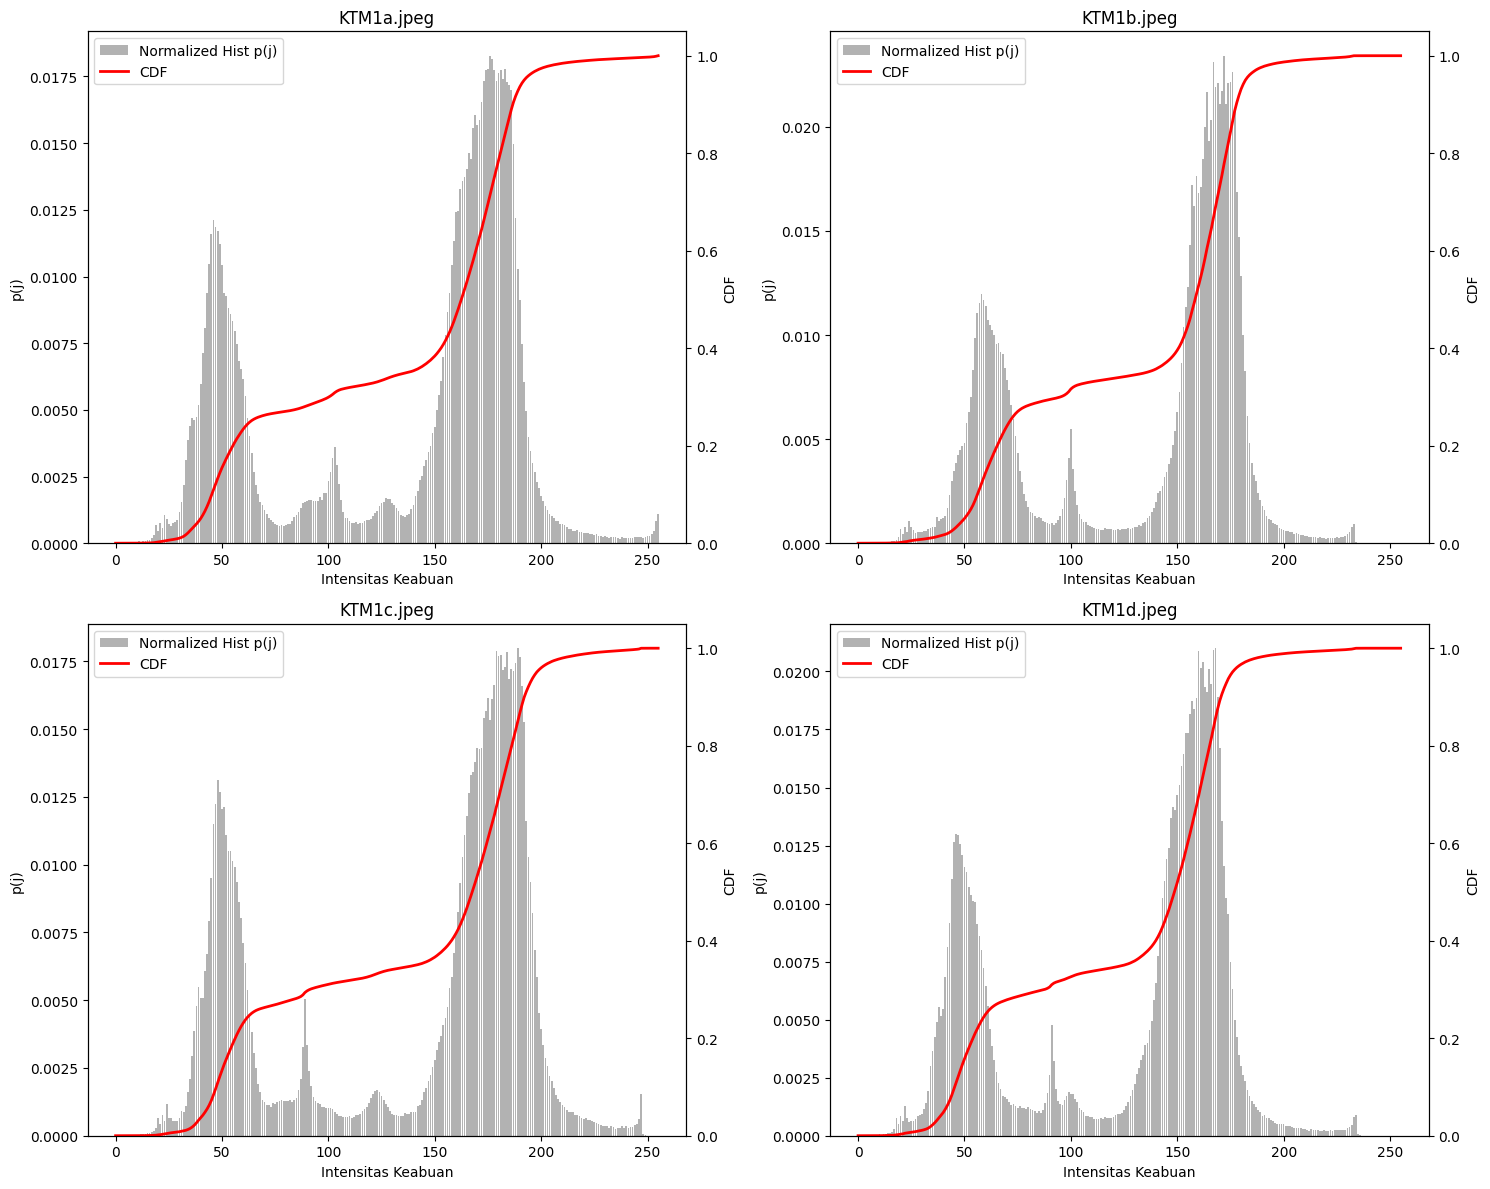

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = '/content/drive/MyDrive/PCVK/Gambar/'
ktm_files = ['KTM1a.jpeg', 'KTM1b.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg']

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.ravel()

for i, file_name in enumerate(ktm_files):
    img_path = os.path.join(base_path, file_name)
    img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(f"Gambar {file_name} tidak ditemukan di: {img_path}")

    # 1. Hitung histogram
    hist, bins = np.histogram(img.flatten(), bins=256, range=[0,256])

    # 2. Normalisasi Histogram p(j) = hist / total_pixel
    pdf = hist / img.size

    # 3. Hitung CDF
    cdf = pdf.cumsum()

    # Plotting PDF
    ax = axs[i]
    ax.bar(range(256), pdf, color='gray', alpha=0.6, label='Normalized Hist p(j)')

    # Sumbu Y sekunder untuk CDF
    ax_cdf = ax.twinx()
    ax_cdf.plot(range(256), cdf, color='red', linewidth=2, label='CDF')
    ax_cdf.set_ylim(0, 1.05)

    ax.set_title(file_name)
    ax.set_xlabel('Intensitas Keabuan')
    ax.set_ylabel('p(j)')
    ax_cdf.set_ylabel('CDF')

    # Gabungkan legend
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax_cdf.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

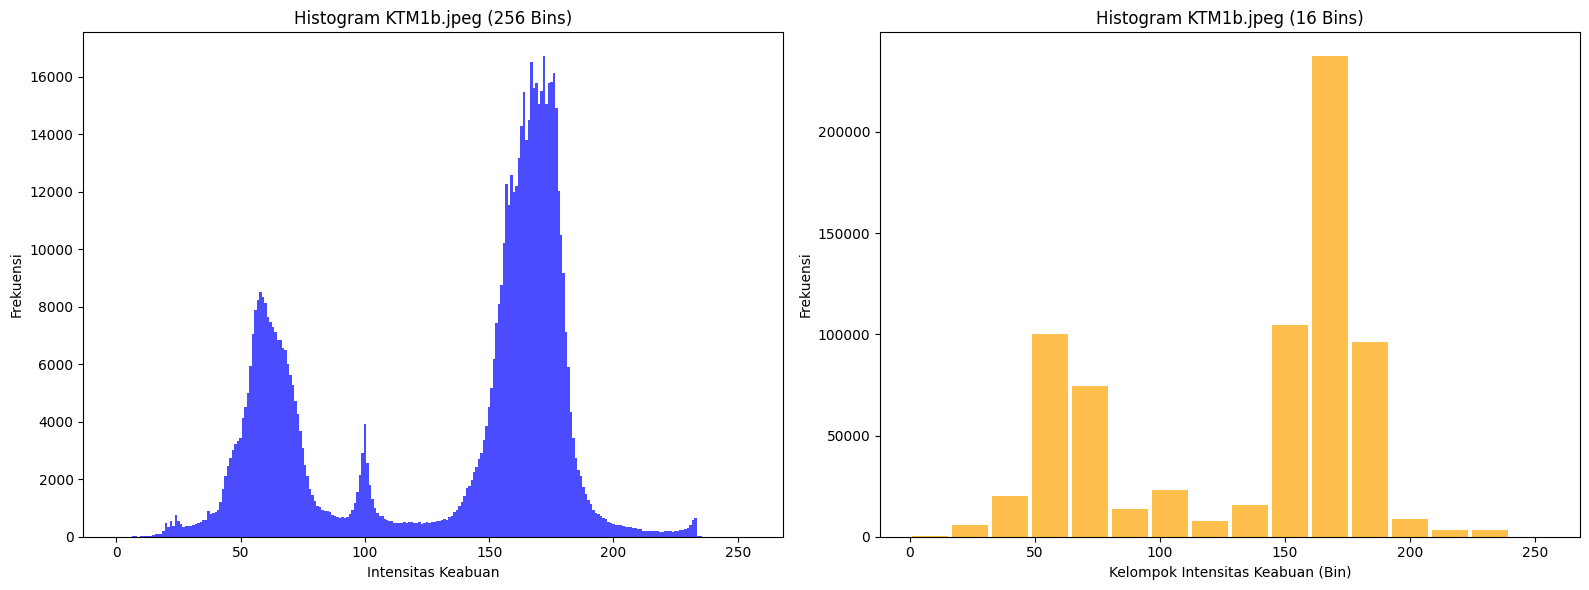

In [15]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

ktm_path = '/content/drive/MyDrive/PCVK/Gambar/KTM1b.jpeg'
img_ktm = cv.imread(ktm_path, cv.IMREAD_GRAYSCALE)

if img_ktm is None:
    raise FileNotFoundError(f"Gambar KTM1b.jpeg tidak ditemukan di: {ktm_path}")

# Definisikan parameter bins yang dikurangi (misalkan PARAM['bins'] = 16)
reduced_bins = 16

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Histogram 256 Bins
hist_256, bins_256 = np.histogram(img_ktm.flatten(), bins=256, range=[0, 256])
axs[0].bar(range(256), hist_256, color='blue', alpha=0.7, width=1.0)
axs[0].set_title('Histogram KTM1b.jpeg (256 Bins)')
axs[0].set_xlabel('Intensitas Keabuan')
axs[0].set_ylabel('Frekuensi')

# Plot 2: Histogram dengan Jumlah Bins Dikurangi (Reduced Bins)
hist_reduced, bins_reduced = np.histogram(img_ktm.flatten(), bins=reduced_bins, range=[0, 256])
bin_width = 256 / reduced_bins
bin_centers = np.arange(reduced_bins) * bin_width + (bin_width / 2)
axs[1].bar(bin_centers, hist_reduced, color='orange', alpha=0.7, width=bin_width * 0.9)
axs[1].set_title(f'Histogram KTM1b.jpeg ({reduced_bins} Bins)')
axs[1].set_xlabel('Kelompok Intensitas Keabuan (Bin)')
axs[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()